# Eigendecomposition

Notebook ini merangkum Chapter 13 dari *Practical Linear Algebra for Data Science*. Chapter ini membahas **eigendecomposition**, yaitu proses menguraikan square matrix menjadi pasangan **eigenvalue** dan **eigenvector**.

Pembahasan dibuat mengikuti format Chapter 11: ada tujuan pembelajaran, ringkasan chapter, struktur pembahasan, penjelasan teori per bagian, rumus matematis yang relevan, kode inti, ringkasan konsep, dan kesimpulan.

## Tujuan Pembelajaran

- Memahami bahwa eigendecomposition hanya berlaku untuk square matrix.
- Menjelaskan arti eigenvalue dan eigenvector secara geometris.
- Menggunakan persamaan dasar eigenvalue, yaitu $Av=\lambda v$.
- Menjelaskan hubungan eigenvalue dengan characteristic polynomial.
- Memahami bahwa eigenvector berasal dari null space matrix yang sudah di-shift oleh eigenvalue.
- Melakukan diagonalization dalam bentuk $A=V\Lambda V^{-1}$.
- Memahami sifat khusus symmetric matrices dalam eigendecomposition.
- Menjelaskan hubungan singular matrix dengan zero-valued eigenvalue.
- Memahami quadratic form dan definiteness.
- Mengenal generalized eigendecomposition.

## Ringkasan Chapter

Chapter ini menjelaskan eigendecomposition sebagai salah satu konsep paling penting dalam linear algebra untuk data science. Eigendecomposition digunakan untuk menemukan pasangan eigenvalue dan eigenvector dari sebuah square matrix. Eigenvector menunjukkan arah khusus yang tidak berubah arah ketika dikalikan dengan matrix, sedangkan eigenvalue menunjukkan besar scaling pada arah tersebut.

Chapter ini menekankan bahwa eigendecomposition memiliki banyak interpretasi. Secara geometris, eigenvector adalah arah yang hanya mengalami stretching atau shrinking. Dalam statistik, eigendecomposition digunakan pada Principal Components Analysis (PCA), yaitu untuk menemukan arah variance terbesar dalam data multivariate. Konsep ini juga berkaitan dengan noise reduction dan dimension reduction karena eigenvalues kecil dapat dianggap merepresentasikan arah informasi yang relatif kecil.

Bagian berikutnya membahas cara menemukan eigenvalues dan eigenvectors secara matematis. Eigenvalues diperoleh dari characteristic polynomial, yaitu determinant dari matrix yang sudah di-shift oleh scalar $\lambda$. Setelah eigenvalue diperoleh, eigenvector dicari sebagai basis vector dari null space matrix $A-\lambda I$.

Chapter ini juga membahas diagonalization, yaitu cara menulis matrix sebagai kombinasi eigenvectors dan eigenvalues dalam bentuk $A=V\Lambda V^{-1}$. Selain itu, symmetric matrices dibahas secara khusus karena memiliki eigenvectors yang orthogonal dan eigenvalues yang real-valued. Terakhir, chapter memperkenalkan definiteness melalui tanda eigenvalues dan generalized eigendecomposition dalam bentuk $Av=\lambda Bv$.

## Struktur Pembahasan Chapter

| Bagian | Inti Pembahasan |
|---|---|
| Just for Squares | Eigendecomposition hanya berlaku untuk square matrix. |
| Interpretations | Eigenvalue dan eigenvector dapat dipahami dari perspektif geometri, statistik, noise reduction, dan data compression. |
| Finding Eigenvalues | Eigenvalues diperoleh dari characteristic polynomial. |
| Finding Eigenvectors | Eigenvectors adalah basis dari null space matrix $A-\lambda I$. |
| Diagonalization | Square matrix dapat direpresentasikan sebagai $A=V\Lambda V^{-1}$. |
| Symmetric Matrices | Symmetric matrix memiliki eigenvectors orthogonal dan eigenvalues real-valued. |
| Singular Matrices | Singular matrix tetap bisa dieigendecompose dan memiliki minimal satu eigenvalue nol. |
| Quadratic Form and Definiteness | Definiteness ditentukan oleh tanda eigenvalues. |
| Generalized Eigendecomposition | Bentuk umum eigendecomposition untuk dua matrix: $Av=\lambda Bv$. |

## Persiapan Library

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

try:
    from scipy.linalg import eigh
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

np.random.seed(2024)

## Just for Squares

Eigendecomposition hanya didefinisikan untuk **square matrix**. Jika matrix berukuran $M \times N$ dan $M \ne N$, maka matrix tersebut tidak dapat dieigendecompose. Untuk nonsquare matrix, chapter berikutnya membahas pendekatan lain, yaitu Singular Value Decomposition (SVD).

Untuk square matrix berukuran $M \times M$, terdapat:

- $M$ eigenvalues,
- $M$ corresponding eigenvectors.

Tujuan eigendecomposition adalah menemukan pasangan scalar-vector tersebut.

## Interpretasi Geometris Eigenvalue dan Eigenvector

Secara geometris, eigenvector adalah vector yang tidak berubah arah ketika dikalikan dengan matrix. Matrix hanya melakukan stretching atau shrinking terhadap vector tersebut.

### Persamaan Eigenvalue

$$
Av = \lambda v
$$

Keterangan:

- $A$ = square matrix
- $v$ = eigenvector
- $\lambda$ = eigenvalue
- $Av$ = hasil transformasi matrix terhadap vector
- $\lambda v$ = hasil scaling vector oleh eigenvalue

Persamaan ini tidak berarti matrix sama dengan scalar. Maknanya adalah efek matrix $A$ terhadap vector $v$ sama dengan efek scalar $\lambda$ terhadap vector yang sama.

In [2]:
A = np.array([
    [2, 1],
    [1, 2]
])

evals, evecs = np.linalg.eig(A)

print("Eigenvalues:")
print(evals)

print("\nEigenvectors:")
print(evecs)

Eigenvalues:
[3. 1.]

Eigenvectors:
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


## Verifikasi Persamaan Eigenvalue

Eigenvectors disimpan pada **columns** dari matrix hasil `np.linalg.eig()`, bukan pada rows. Kesalahan mengambil rows dapat menyebabkan interpretasi yang salah, khususnya pada square matrix karena kode tetap bisa berjalan tanpa error.

In [3]:
for i in range(len(evals)):
    v = evecs[:, i]
    left_side = A @ v
    right_side = evals[i] * v

    print(f"Eigenpair {i+1}")
    print("A @ v       :", np.round(left_side, 4))
    print("lambda * v  :", np.round(right_side, 4))
    print("Equal?      :", np.allclose(left_side, right_side))
    print()

Eigenpair 1
A @ v       : [2.1213 2.1213]
lambda * v  : [2.1213 2.1213]
Equal?      : True

Eigenpair 2
A @ v       : [-0.7071  0.7071]
lambda * v  : [-0.7071  0.7071]
Equal?      : True



## Visualisasi Geometris Eigenvector

Kode berikut menunjukkan bahwa eigenvector dan hasil transformasinya tetap berada pada garis arah yang sama. Perbedaannya hanya pada skala panjang vector.

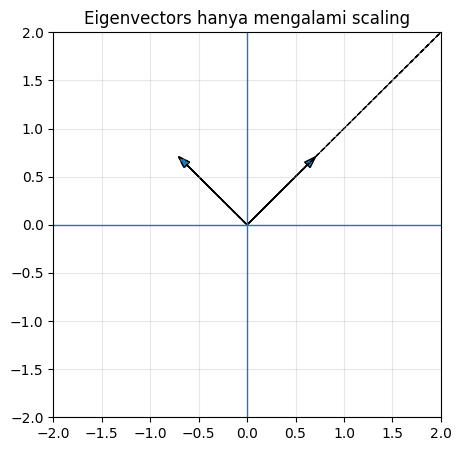

In [4]:
v1 = evecs[:, 0]
v2 = evecs[:, 1]

Av1 = A @ v1
Av2 = A @ v2

plt.figure(figsize=(5, 5))

plt.arrow(0, 0, v1[0], v1[1], head_width=.08, length_includes_head=True, label="v1")
plt.arrow(0, 0, Av1[0], Av1[1], head_width=.08, length_includes_head=True, linestyle="--")
plt.arrow(0, 0, v2[0], v2[1], head_width=.08, length_includes_head=True)
plt.arrow(0, 0, Av2[0], Av2[1], head_width=.08, length_includes_head=True, linestyle="--")

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.grid(alpha=0.3)
plt.title("Eigenvectors hanya mengalami scaling")
plt.show()

## Statistics: Principal Components Analysis

Dalam statistik, eigendecomposition digunakan untuk menemukan arah variance terbesar pada data multivariate. Salah satu aplikasi utamanya adalah **Principal Components Analysis (PCA)**.

Pada PCA, eigendecomposition dilakukan terhadap covariance matrix. Eigenvalues menunjukkan seberapa besar variance yang dijelaskan oleh masing-masing component. Scree plot digunakan untuk melihat apakah data didominasi oleh satu component atau beberapa component besar.

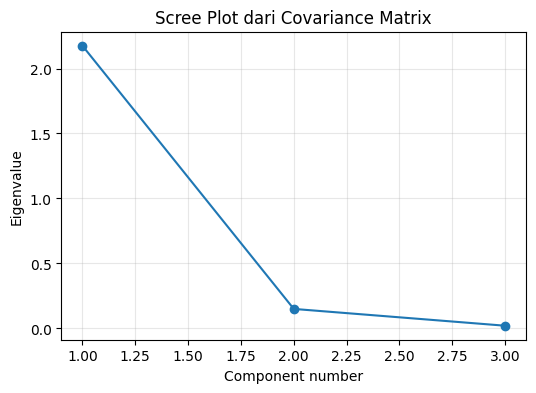

In [5]:
# Simulasi covariance matrix dengan satu arah variance dominan
X = np.random.randn(300, 3)
X[:, 1] = X[:, 0] * 0.8 + np.random.randn(300) * 0.2
X[:, 2] = X[:, 0] * 0.6 + np.random.randn(300) * 0.4

X = X - X.mean(axis=0)
C = X.T @ X / (X.shape[0] - 1)

evals_cov, evecs_cov = np.linalg.eig(C)
evals_sorted = np.sort(evals_cov)[::-1]

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(evals_sorted)+1), evals_sorted, marker="o")
plt.xlabel("Component number")
plt.ylabel("Eigenvalue")
plt.title("Scree Plot dari Covariance Matrix")
plt.grid(alpha=0.3)
plt.show()

## Noise Reduction dan Dimension Reduction

Chapter menjelaskan bahwa eigenvalues kecil sering dikaitkan dengan arah variance yang kecil. Dalam konteks noise reduction, arah dengan eigenvalue kecil dapat dianggap sebagai kontribusi noise atau informasi yang tidak dominan.

Untuk dimension reduction, dataset dapat direkonstruksi menggunakan eigenvalue/eigenvector pairs yang besar saja. Prinsip ini juga digunakan dalam data compression, meskipun dalam praktik modern SVD lebih umum digunakan untuk kompresi data.

## Finding Eigenvalues

Untuk mencari eigenvalues, chapter memulai dari persamaan eigenvalue:

$$
Av = \lambda v
$$

Kemudian persamaan disusun ulang:

$$
Av - \lambda v = 0
$$

Karena scalar tidak dapat langsung dikurangkan dari matrix, digunakan identity matrix:

$$
(A-\lambda I)v = 0
$$

Keterangan:

- $A-\lambda I$ = matrix $A$ yang di-shift oleh scalar $\lambda$
- $v$ = eigenvector
- Persamaan ini menunjukkan bahwa eigenvector berada di null space dari matrix $A-\lambda I$

Agar memiliki nontrivial null space, matrix $A-\lambda I$ harus singular. Karena singular matrix memiliki determinant 0, maka eigenvalue dicari dari:

$$
\det(A-\lambda I)=0
$$

Persamaan ini disebut **characteristic polynomial**.

## Characteristic Polynomial untuk Matrix 2 × 2

Untuk matrix:

$$
A =
\begin{bmatrix}
a & b \\
c & d
\end{bmatrix}
$$

maka:

$$
A-\lambda I =
\begin{bmatrix}
a-\lambda & b \\
c & d-\lambda
\end{bmatrix}
$$

Characteristic polynomial:

$$
\det(A-\lambda I)=0
$$

$$
(a-\lambda)(d-\lambda)-bc=0
$$

$$
\lambda^2-(a+d)\lambda+ad-bc=0
$$

Karena matrix $2 \times 2$ menghasilkan polynomial orde dua, maka terdapat dua eigenvalues. Secara umum, matrix $M \times M$ memiliki $M$ eigenvalues.

In [6]:
matrix = np.array([
    [1, 2],
    [3, 4]
])

evals, evecs = np.linalg.eig(matrix)

print("Eigenvalues:")
print(np.round(evals, 4))

Eigenvalues:
[-0.3723  5.3723]


## Finding Eigenvectors

Setelah eigenvalues ditemukan, eigenvectors diperoleh dari null space matrix yang sudah di-shift oleh eigenvalue.

### Rumus Eigenvector sebagai Null Space

$$
v_i \in N(A-\lambda_i I)
$$

Keterangan:

- $v_i$ = eigenvector ke-$i$
- $\lambda_i$ = eigenvalue ke-$i$
- $N(A-\lambda_i I)$ = null space dari shifted matrix

Contoh chapter menggunakan matrix:

$$
A =
\begin{bmatrix}
1 & 2 \\
2 & 1
\end{bmatrix}
$$

dengan eigenvalue $\lambda_1=3$. Jika matrix di-shift:

$$
A-3I =
\begin{bmatrix}
-2 & 2 \\
2 & -2
\end{bmatrix}
$$

Vector $\begin{bmatrix}1\\1\end{bmatrix}$ berada pada null space matrix tersebut, sehingga menjadi eigenvector untuk $\lambda=3$.

In [7]:
A = np.array([
    [1, 2],
    [2, 1]
])

evals, evecs = np.linalg.eig(A)

print("Eigenvalues:")
print(evals)

print("\nEigenvectors in columns:")
print(evecs)

# Cek shifted matrix untuk eigenvalue 3
lam = 3
shifted = A - lam*np.eye(2)
v = np.array([1, 1])

print("\n(A - 3I) @ [1,1]:")
print(shifted @ v)

Eigenvalues:
[ 3. -1.]

Eigenvectors in columns:
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]

(A - 3I) @ [1,1]:
[0. 0.]


## Sign and Scale Indeterminacy

Eigenvectors penting karena arahnya, bukan magnitudenya. Jika $v$ adalah eigenvector, maka $\alpha v$ juga eigenvector untuk scalar nonzero $\alpha$.

### Rumus Scale Indeterminacy

$$
A(\alpha v)=\lambda(\alpha v)
$$

Keterangan:

- $\alpha$ = scalar nonzero
- $v$ dan $\alpha v$ memiliki arah yang sama
- Magnitude eigenvector dapat berubah tanpa mengubah statusnya sebagai eigenvector

Selain skala, tanda eigenvector juga tidak unik. Vector $v$ dan $-v$ dapat sama-sama menjadi eigenvector.

In [8]:
v = evecs[:, 0]
v_scaled = 4 * v

print("Original eigenvector:")
print(v)

print("\nScaled eigenvector:")
print(v_scaled)

print("\nA @ scaled v and lambda * scaled v equal?")
print(np.allclose(A @ v_scaled, evals[0] * v_scaled))

Original eigenvector:
[0.70710678 0.70710678]

Scaled eigenvector:
[2.82842712 2.82842712]

A @ scaled v and lambda * scaled v equal?
True


## Diagonalizing a Square Matrix

Persamaan eigenvalue untuk semua eigenvalue/eigenvector pairs dapat ditulis dalam bentuk matrix.

### Rumus Diagonalization

$$
AV = V\Lambda
$$

Bentuk yang ekuivalen:

$$
A = V\Lambda V^{-1}
$$

dan:

$$
\Lambda = V^{-1}AV
$$

Keterangan:

- $V$ = matrix yang columns-nya berisi eigenvectors
- $\Lambda$ = diagonal matrix yang diagonalnya berisi eigenvalues
- $V^{-1}$ = inverse dari eigenvectors matrix

Diagonalization menunjukkan bahwa matrix $A$ menjadi diagonal dalam basis eigenvectors.

In [9]:
A = np.array([
    [4, 2],
    [1, 3]
])

evals, V = np.linalg.eig(A)
L = np.diag(evals)

A_reconstructed = V @ L @ np.linalg.inv(V)

print("Original A:")
print(A)

print("\nReconstructed A:")
print(np.round(A_reconstructed, 6))

print("\nFrobenius reconstruction error:")
print(np.linalg.norm(A - A_reconstructed, "fro"))

Original A:
[[4 2]
 [1 3]]

Reconstructed A:
[[4. 2.]
 [1. 3.]]

Frobenius reconstruction error:
1.0877919644084146e-15


## Symmetric Matrices: Orthogonal Eigenvectors

Symmetric matrices memiliki sifat khusus: eigenvectors-nya saling orthogonal. Jika eigenvectors dinormalisasi menjadi unit length, maka matrix eigenvectors menjadi orthogonal matrix.

### Rumus Orthogonal Eigenvectors

$$
V^TV = I
$$

Keterangan:

- $V$ = matrix eigenvectors dari symmetric matrix
- $V^T$ = transpose dari $V$
- $I$ = identity matrix

Implikasinya, inverse dari $V$ mudah dihitung:

$$
V^{-1}=V^T
$$

In [10]:
A = np.random.randint(-3, 4, (3, 3))
A = A.T @ A  # symmetric matrix

evals, V = np.linalg.eig(A)

print("A symmetric?")
print(np.allclose(A, A.T))

print("\nV.T @ V:")
print(np.round(V.T @ V, 6))

A symmetric?
True

V.T @ V:
[[ 1. -0.  0.]
 [-0.  1.  0.]
 [ 0.  0.  1.]]


## Symmetric Matrices: Real-Valued Eigenvalues

Symmetric matrices juga dijamin memiliki eigenvalues yang real-valued. Sebaliknya, nonsymmetric matrix dengan entries real masih dapat memiliki complex-valued eigenvalues.

Jika bekerja pada symmetric matrix, chapter menyarankan penggunaan `np.linalg.eigh()` karena lebih sesuai untuk Hermitian/symmetric matrix dan dapat lebih stabil secara numerik.

In [11]:
A_nonsym = np.array([
    [-3, -3, 0],
    [ 3, -2, 3],
    [ 0,  1, 2]
])

L_nonsym, _ = np.linalg.eig(A_nonsym)

A_sym = np.array([
    [-3, -3, 0],
    [-3, -2, 1],
    [ 0,  1, 2]
])

L_sym, _ = np.linalg.eig(A_sym)

print("Eigenvalues nonsymmetric matrix:")
print(L_nonsym.reshape(-1, 1))

print("\nEigenvalues symmetric matrix:")
print(L_sym.reshape(-1, 1))

Eigenvalues nonsymmetric matrix:
[[-2.744739  +2.85172624j]
 [-2.744739  -2.85172624j]
 [ 2.48947801+0.j        ]]

Eigenvalues symmetric matrix:
[[-5.59707146]
 [ 0.22606174]
 [ 2.37100972]]


## Eigendecomposition of Singular Matrices

Singular matrix tetap dapat dieigendecompose. Hal penting dari singular matrix adalah minimal ada satu eigenvalue bernilai nol.

Contoh chapter menggunakan matrix:

$$
A =
\begin{bmatrix}
1 & 4 & 7 \\
2 & 5 & 8 \\
3 & 6 & 9
\end{bmatrix}
$$

Matrix ini reduced-rank dan memiliki satu eigenvalue yang mendekati nol. Zero-valued eigenvalue menunjukkan adanya nontrivial null space.

In [12]:
A = np.array([
    [1, 4, 7],
    [2, 5, 8],
    [3, 6, 9]
])

L, V = np.linalg.eig(A)

print("Rank =", np.linalg.matrix_rank(A))
print("\nEigenvalues:")
print(np.round(L, 4))

print("\nEigenvectors:")
print(np.round(V, 4))

Rank = 2

Eigenvalues:
[16.1168 -1.1168 -0.    ]

Eigenvectors:
[[-0.4645 -0.8829  0.4082]
 [-0.5708 -0.2395 -0.8165]
 [-0.677   0.4039  0.4082]]


## Quadratic Form

Quadratic form adalah hasil pre- dan postmultiplication square matrix oleh vector yang sama.

### Rumus Quadratic Form

$$
w^TAw = \alpha
$$

Keterangan:

- $A$ = square matrix
- $w$ = vector
- $\alpha$ = scalar hasil quadratic form

Quadratic form digunakan untuk memahami tanda output matrix terhadap seluruh kemungkinan vector. Konsep ini menjadi dasar untuk definiteness.

In [13]:
A = np.array([
    [2, 4],
    [0, 3]
])

w = np.array([1, 2])

alpha = w.T @ A @ w

print("Quadratic form result:", alpha)

Quadratic form result: 22


## Definiteness

Definiteness adalah karakteristik square matrix yang ditentukan oleh tanda eigenvalues. Chapter membagi definiteness menjadi lima kategori.

| Category | Quadratic Form | Eigenvalues | Invertible |
|---|---|---|---|
| Positive definite | Positive | Semua positif | Yes |
| Positive semidefinite | Nonnegative | Positif dan 0 | No |
| Indefinite | Positive dan negative | Positif dan negatif | Depends |
| Negative semidefinite | Nonpositive | Negatif dan 0 | No |
| Negative definite | Negative | Semua negatif | Yes |

Kategori yang paling relevan dalam data science adalah positive definite dan positive semidefinite.

In [14]:
def classify_definiteness(A):
    evals = np.linalg.eigvals(A)

    if np.all(evals > 1e-10):
        return "Positive definite"
    elif np.all(evals >= -1e-10):
        return "Positive semidefinite"
    elif np.all(evals < -1e-10):
        return "Negative definite"
    elif np.all(evals <= 1e-10):
        return "Negative semidefinite"
    else:
        return "Indefinite"

A_pd = np.array([
    [2, 1],
    [1, 2]
])

A_indef = np.array([
    [-9, 4],
    [3, 9]
])

print("Eigenvalues A_pd:", np.linalg.eigvals(A_pd))
print("Category:", classify_definiteness(A_pd))

print("\nEigenvalues A_indef:", np.linalg.eigvals(A_indef))
print("Category:", classify_definiteness(A_indef))

Eigenvalues A_pd: [3. 1.]
Category: Positive definite

Eigenvalues A_indef: [-9.64365076  9.64365076]
Category: Indefinite


## $A^TA$ adalah Positive (Semi)definite

Matrix yang dapat ditulis sebagai product matrix dengan transpose-nya selalu positive definite atau positive semidefinite.

### Rumus Quadratic Form untuk $A^TA$

Misalkan:

$$
S=A^TA
$$

maka:

$$
w^TSw
=
w^TA^TAw
=
(Aw)^T(Aw)
=
\|Aw\|^2
$$

Karena squared norm tidak mungkin negatif, maka $A^TA$ selalu positive semidefinite. Jika $A$ full-rank, maka eigenvalues-nya positive.

In [15]:
A = np.random.randn(5, 3)
S = A.T @ A

evals = np.linalg.eigvals(S)

print("Eigenvalues of A.T @ A:")
print(np.round(evals, 6))

print("\nAll nonnegative?")
print(np.all(evals >= -1e-10))

Eigenvalues of A.T @ A:
[12.159505  5.763757  0.519242]

All nonnegative?
True


## Generalized Eigendecomposition

Generalized eigendecomposition mengganti identity matrix pada persamaan eigenvalue dengan matrix lain.

### Rumus Generalized Eigendecomposition

$$
Av = \lambda Bv
$$

Keterangan:

- $A$ dan $B$ = matrix
- $\lambda$ = generalized eigenvalue
- $v$ = generalized eigenvector

Konsep ini juga disebut simultaneous diagonalization of two matrices. Pair $(\lambda, v)$ bukan milik $A$ saja atau $B$ saja, melainkan merepresentasikan hubungan dua matrix.

Secara konseptual dapat dipikirkan sebagai:

$$
C = AB^{-1}
$$

$$
Cv = \lambda v
$$

Namun dalam praktik, generalized eigendecomposition tidak selalu membutuhkan $B$ untuk dihitung inverse-nya secara eksplisit.

In [16]:
if SCIPY_AVAILABLE:
    A = np.random.randn(4, 4)
    A = A @ A.T

    B = np.random.randn(4, 4)
    B = B @ B.T + A/10

    evals, evecs = eigh(A, B)

    print("Generalized eigenvalues:")
    print(np.round(evals, 4))

    print("\nCheck V.T @ B @ V:")
    print(np.round(evecs.T @ B @ evecs, 4))
else:
    print("SciPy tidak tersedia di environment ini.")

Generalized eigenvalues:
[0.3226 0.4235 2.6777 8.7667]

Check V.T @ B @ V:
[[ 1.  0. -0. -0.]
 [ 0.  1.  0.  0.]
 [-0.  0.  1. -0.]
 [-0.  0.  0.  1.]]


## Subtleties of Eigendecomposition

Chapter menutup pembahasan dengan mengingatkan bahwa eigendecomposition memiliki banyak detail lanjutan. Beberapa di antaranya:

- Jumlah eigenvalues sama dengan trace matrix.
- Product eigenvalues sama dengan determinant matrix.
- Tidak semua square matrix dapat didiagonalize.
- Repeated eigenvalues dapat memengaruhi eigenvectors.
- Complex eigenvalues dari real-valued matrices dapat muncul pada complex plane.

Notebook ini hanya mengambil konsep utama yang dibutuhkan untuk data science dan untuk mempersiapkan pembahasan SVD pada chapter berikutnya.

## Ringkasan Konsep Penting

| Konsep | Ringkasan |
|---|---|
| Eigendecomposition | Proses menemukan eigenvalue/eigenvector pairs dari square matrix. |
| Eigenvalue | Scalar yang menunjukkan besar stretching/shrinking. |
| Eigenvector | Arah khusus yang tidak berubah arah setelah matrix-vector multiplication. |
| Eigenvalue equation | $Av=\lambda v$. |
| Characteristic polynomial | $\det(A-\lambda I)=0$, digunakan untuk mencari eigenvalues. |
| Shifted matrix | Matrix $A-\lambda I$. |
| Eigenvector null space | Eigenvector berada di null space dari $A-\lambda I$. |
| Diagonalization | Representasi matrix sebagai $A=V\Lambda V^{-1}$. |
| Symmetric matrix | Memiliki orthogonal eigenvectors dan real-valued eigenvalues. |
| Singular matrix | Tetap dapat dieigendecompose dan memiliki minimal satu zero-valued eigenvalue. |
| Quadratic form | Bentuk $w^TAw$ yang menghasilkan scalar. |
| Definiteness | Kategori matrix berdasarkan tanda eigenvalues. |
| Positive semidefinite | Semua eigenvalues nonnegative; covariance matrix termasuk kategori ini. |
| Generalized eigendecomposition | Bentuk $Av=\lambda Bv$ untuk dua matrix. |

## Kesimpulan Chapter

Chapter ini memperkenalkan eigendecomposition sebagai proses menemukan pasangan eigenvalue dan eigenvector dari square matrix. Eigenvector adalah arah khusus yang tidak berubah arah ketika matrix bekerja padanya, sedangkan eigenvalue menunjukkan besar perubahan skala pada arah tersebut.

Eigenvalues ditemukan melalui characteristic polynomial, yaitu $\det(A-\lambda I)=0$. Setelah eigenvalue diperoleh, eigenvector dicari sebagai basis dari null space matrix $A-\lambda I$. Hubungan ini menjelaskan mengapa eigenvectors berkaitan erat dengan null space dan singularity.

Diagonalization merangkum seluruh eigenvalue/eigenvector pairs dalam bentuk matrix equation $A=V\Lambda V^{-1}$. Bentuk ini menunjukkan bahwa matrix dapat menjadi diagonal jika dilihat dari basis eigenvectors.

Symmetric matrices memiliki sifat khusus yang sangat penting untuk data science: eigenvectors-nya orthogonal dan eigenvalues-nya real-valued. Karena itu, banyak matrix dalam data science seperti covariance matrix lebih mudah dianalisis menggunakan eigendecomposition.

Chapter ini juga menjelaskan bahwa singular matrix tetap dapat dieigendecompose, tetapi memiliki minimal satu eigenvalue nol. Selain itu, definiteness matrix ditentukan oleh tanda eigenvalues, dan matrix berbentuk $A^TA$ selalu positive semidefinite. Terakhir, generalized eigendecomposition memperluas persamaan eigenvalue menjadi $Av=\lambda Bv$, yang digunakan pada beberapa metode lanjutan seperti classification analysis dan signal processing.